# 05 — Top Products Performance
Identify the top 20 products by revenue and the top 15 by profit margin.

## Setup — Spark Session & Load HDFS Tables

In [1]:
import os, sys

os.environ["JAVA_HOME"]             = "/usr/local/java"
os.environ["SPARK_HOME"]            = "/usr/local/spark"
os.environ["HADOOP_CONF_DIR"]       = "/usr/local/hadoop/etc/hadoop"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
        .appName("05 — Top Products Performance")
        .master("spark://namenode:7077")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

HDFS_BASE = "hdfs:///data"

def load_csv(name, renames):
    df = (spark.read
          .option("header", "true")
          .option("inferSchema", "true")
          .csv(f"{HDFS_BASE}/{name}.csv"))
    for old, new in renames.items():
        df = df.withColumnRenamed(old, new)
    df.createOrReplaceTempView(name)
    return df

load_csv("customers",   {"Customer ID":"customer_id","Customer Name":"customer_name","Segment":"segment"})
load_csv("orders",      {"Order ID":"order_id","Order Date":"order_date","Ship Date":"ship_date",
                          "Ship Mode":"ship_mode","Customer ID":"customer_id","Postal Code":"postal_code"})
load_csv("order_items", {"Row ID":"row_id","Order ID":"order_id","Product ID":"product_id",
                          "Sales":"sales","Quantity":"quantity","Discount":"discount","Profit":"profit"})
load_csv("products",    {"Product ID":"product_id","Product Name":"product_name",
                          "Category":"category","Sub-Category":"sub_category"})
load_csv("locations",   {"Postal Code":"postal_code","City":"city","State":"state",
                          "Country":"country","Region":"region"})

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

CHARTS_DIR = "/usr/local/hadoop/etc/hadoop/assessment-2/charts"
os.makedirs(CHARTS_DIR, exist_ok=True)
print("Ready.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/28 17:00:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Ready.


## Query

In [2]:
top_sales = spark.sql('''
    SELECT p.product_name, p.category,
           ROUND(SUM(oi.sales),  2) AS total_sales,
           ROUND(SUM(oi.profit), 2) AS total_profit,
           SUM(oi.quantity)         AS total_qty
    FROM order_items oi JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_name, p.category ORDER BY total_sales DESC LIMIT 20
''').toPandas()

top_profit = spark.sql('''
    SELECT p.product_name, p.category,
           ROUND(SUM(oi.profit), 2) AS total_profit
    FROM order_items oi JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_name, p.category ORDER BY total_profit DESC LIMIT 15
''').toPandas()
print(top_sales[["product_name","category","total_sales"]].head())

                                        product_name         category  \
0              Canon imageCLASS 2200 Advanced Copier       Technology   
1  Fellowes PB500 Electric Punch Plastic Comb Bin...  Office Supplies   
2  Cisco TelePresence System EX90 Videoconferenci...       Technology   
3       HON 5400 Series Task Chairs for Big and Tall        Furniture   
4         GBC DocuBind TL300 Electric Binding System  Office Supplies   

   total_sales  
0     61599.82  
1     27453.38  
2     22638.48  
3     21870.58  
4     19823.48  


## Visualisation

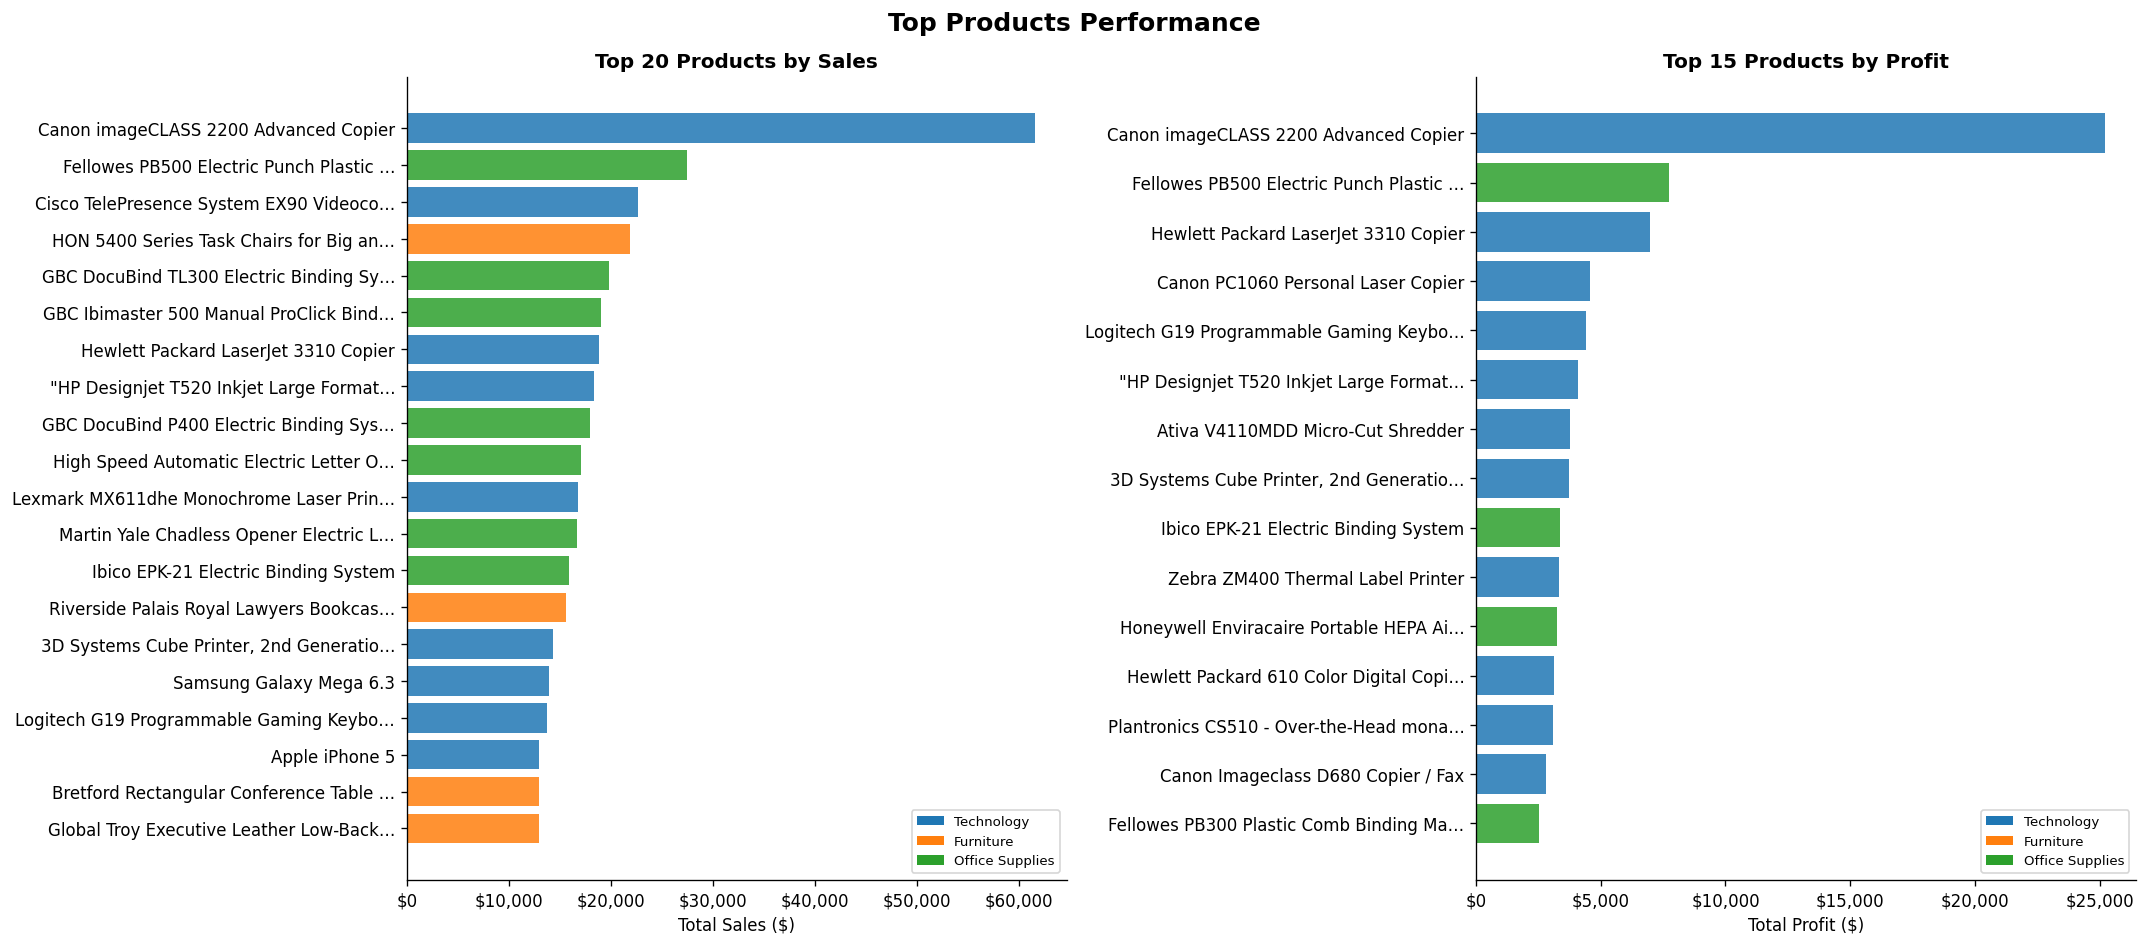

Chart saved to /usr/local/hadoop/etc/hadoop/assessment-2/charts/05_top_products.png


In [3]:
from matplotlib.patches import Patch
cat_c = {"Technology":"#1f77b4","Furniture":"#ff7f0e","Office Supplies":"#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

short_s = [n[:38]+"…" if len(n)>38 else n for n in top_sales["product_name"]]
c_s = [cat_c.get(c,"#999") for c in top_sales["category"]]
axes[0].barh(short_s[::-1], top_sales["total_sales"][::-1], color=c_s[::-1], alpha=0.85)
axes[0].set_title("Top 20 Products by Sales", fontweight="bold"); axes[0].set_xlabel("Total Sales ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[0].legend(handles=[Patch(facecolor=v,label=k) for k,v in cat_c.items()], fontsize=8)

short_p = [n[:38]+"…" if len(n)>38 else n for n in top_profit["product_name"]]
c_p = [cat_c.get(c,"#999") for c in top_profit["category"]]
axes[1].barh(short_p[::-1], top_profit["total_profit"][::-1], color=c_p[::-1], alpha=0.85)
axes[1].set_title("Top 15 Products by Profit", fontweight="bold"); axes[1].set_xlabel("Total Profit ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[1].legend(handles=[Patch(facecolor=v,label=k) for k,v in cat_c.items()], fontsize=8)

plt.suptitle("Top Products Performance", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{CHARTS_DIR}/05_top_products.png", bbox_inches="tight")
plt.show()
print(f"Chart saved to {CHARTS_DIR}/05_top_products.png")

## Stop Spark

In [4]:
spark.stop()
print("Spark session stopped.")

Spark session stopped.
